## Madison Austin
## 11/21/25
## CSCI 246
## This notebook contains solutions math equations and Python for problems from Chapter 12.

### Question 12.2.2
### Ice cream comes in two sizes, three flavors, and with any one of five toppings.
### Answer:
With using the multiplicaton $2 x 3 x 5 = 30$
### a) In how many different variations can you order an ice cream? Show your calculations.

### b) Represent these attributes with Python lists in code. Example:
sizes = ["small", "large"] <br>
flavors = ["chocolate", "vanilla", "strawberry"] <br>
toppings = ["fudge", "caramel", "sprinkles", "Reese’s Pieces", "marshmallows"] <br>

### c) Use nested loops to create a list of tuples of possible variations of sizes, flavors and toppings as described above. Print your result.
### d) Use list comprehension to accomplish the same in a single line. Print your result.
### e) Use itertools.product to accomplish the same. Print your result.

In [1]:
# sizes, flavors, toppings
sizes = ["small", "large"]
flavors = ["chocolate", "vanilla", "strawberry"]
toppings = ["fudge", "caramel", "sprinkles", "Reese's Pieces", "marshmallows"]

# c) nested loops -> list of tuples
variations_nested = []
for s in sizes:
    for f in flavors:
        for t in toppings:
            variations_nested.append((s, f, t))
print("nested:", len(variations_nested))

# d) list comprehension
variations_comp = [(s, f, t) for s in sizes for f in flavors for t in toppings]
print("comprehension:", len(variations_comp))

# e) itertools
import itertools
variations_product = list(itertools.product(sizes, flavors, toppings))
print("itertools.product:", len(variations_product))



nested: 30
comprehension: 30
itertools.product: 30


### Question 12.2.3
How many three-letter names are possible in Python such that all letters are lowercase, the middle letter
is a vowel (‘a’, ‘e’, ‘i’, ‘o’, ‘u’), and the other two letters are consonants?
### a. Show your calculations and the result.
### Answer:
there are 5 vowels and 26 lowercase letters in total. 21(26-5)
the count = $21 x 5 x 21 = 21^2 x 5 =2205$
### b. Represent the set of lower case vowels and the set of lower case consonants as Python sets.
### c. Use itertools.product to generate a list of (ordered) letter combinations that satisfy the description of three-letter names given above. Do not print the result.
### d. Compute the length of the list generated in Part c. Does the result match your calculation from Part a? It should.

In [2]:
import itertools
vowels = set(list("aeiou"))
consonants = set(chr(c) for c in range(ord('a'), ord('z')+1)) - vowels

# c) generate combinations
names = list(itertools.product(sorted(consonants), sorted(vowels), sorted(consonants)))

# d) length
print("Computed count:", len(names))
print("Matches math?:", len(names) == 21*5*21)

Computed count: 2205
Matches math?: True


### Question 12.2.6
What is the number of all possible subsets of a set of ten elements, including the empty set and the whole set?
### a. Show your calculations and the result.
### Answer:
powerset is $2^10 = 1024$
### b. Create a Python set that has 10 elements.
### c. Use more_itertools.powerset to create the Python set that represents the powerset of your set of 10 elements. Do not print the result.
### d. Compute the size of the set generated in Part c. Does the result match your calculation from Part a? It should.


In [3]:
# b) set of 10 elements
S = set(range(1, 11))  # {1,...,10}

# c) using itertools.powerset
try:
    import more_itertools as mit
    powerset_iter = mit.powerset(S)
    powerset_list = list(powerset_iter)
    print("Powerset size):", len(powerset_list))
except Exception as e:
    # just incase, should print the same thing
    import itertools
    powerset_list = []
    for r in range(0, len(S)+1):
        for comb in itertools.combinations(S, r):
            powerset_list.append(set(comb))
    print("Powerset size:", len(powerset_list))

print("Matches 2^10 ?:", len(powerset_list) == 2**10)


Powerset size): 1024
Matches 2^10 ?: True


### Question 12.2.8
What is the number of all possible configurations of five disks of different sizes on three pegs in the Tower
of Hanoi puzzle? Remember that we are not allowed to place a bigger disk on top of a smaller one.
### a. Show your calculations and the result.
### Answer:
for a given peg, the disks assigned to that peg are naturally ordered by size (larger below smaller) configuration = $3^5 = 243$
### b. The possible assignments of disks to pegs can be represented as follows:
pegs = [1,2,3]
disks_to_pegs = list(itertools.product(pegs,pegs,pegs,pegs,pegs))

The resulting tuples indicate which peg each disk is assigned to. For example, (3, 1, 1, 2, 3) indicates that the first disc is assigned to peg 3, the second to peg 1, the third to peg 1, the fourth to peg 2,and the fifth to peg 3.

### c. Determine (compute) how many of the tuples in the list from Part b correspond to assignments that use all three pegs.


In [4]:
import itertools
# b) should be 3^5 = 243
pegs = [1,2,3]
disks_to_pegs = list(itertools.product(pegs, repeat=5))
print("Total assignments:", len(disks_to_pegs)) 

# c) how many use all three pegs?
using_all_three = [t for t in disks_to_pegs if set(t) == set(pegs)]
print("Assignments using all three pegs:", len(using_all_three))


Total assignments: 243
Assignments using all three pegs: 150


### Question 12.3.1
How many three-digit integers have all different digits?
### a. Show your calculations and the result.
### Answer:
100 to 999, theres 9 = hundreds, 9 = tens, 8 ones, $9 x 9 x 8 = 648$
### b. In code, iterate through all three digit numbers. Identify and count those that have three different digits. Does the result match your calculation from Part a? It should

In [5]:
count = 0
nums = []
for n in range(100, 1000):
    s = str(n)
    if len(set(s)) == 3:
        count += 1
        nums.append(n)
print("Count:", count)
print("Matches math?:", count == 9*9*8)


Count: 648
Matches math?: True


### Question 12.3.3
How many ways are there to choose “most likely to succeed,” “best athlete,” “best dancer,” “best
dressed,” and “class clown,” a boy and a girl in each category, in a graduating middle school class of 30
girls and 36 boys? The same person cannot be chosen in two categories.
Explain and show your calculations

### Answer:
there is 5 categories, one boy and one girl. the same person can't be in the same two categories. $p(36,5)=36 x 35 x 34 x 33 x 32$ for girls, $p(30,5)= 30 x 29 x 28 x 27 x 26$ for boys

In [6]:
import math
P36_5 = math.perm(36,5)
P30_5 = math.perm(30,5)
total = P36_5 * P30_5
P36_5, P30_5, total

(45239040, 17100720, 773620156108800)

### Question 12.3.6
How many pages will it take to print all possible permutations of letters “ABCDEFGHIJKL”? Each
permutation is printed on a separate line; 60 lines fit on a page.
### a) Explain and show your calculations.
### Answer:
number of permutations- 12! [12!/60]
### b) Use math.perm to do this calculation in Python. Does the result match your calculation from Part a? It should

In [7]:
import math
fact_12 = math.factorial(12)
pages = math.ceil(fact_12 / 60)
fact_12, pages

(479001600, 7983360)

### Question 12.3.8
Two words are called anagrams of each other if they are made up of the same letters used in a different
order: for example, MANGO and AMONG. Jesse decided to write a program that finds all the anagrams of
a given word by generating all possible permutations of its letters and looking up each permutation in a
list of words (obtained in a file). If the program can generate and look up 360 permutations per second,
how long will it take it to find all anagrams of “BINARY”? “DECIMAL”? What about “CONVERSATION”?
### a) Explain and show your calculations.
Binary: 6 letters, 6! = 720, 720/360 = 2 seconds <br>
Decimal: 7 letters, 7! = 5040, 5040/360 = 14 seconds <br>
conversation: 12 letters, im just gonna put it in the code <br>
### b) Use math.perm to do these calculations in Python. Do the results match your calculations from Part a? They should.

In [8]:
import math
from collections import Counter

def time_to_check(word, rate_per_sec=360):
    word = word.lower()
    n = len(word)
    counts = Counter(word)
    denom = 1
    for v in counts.values():
        denom *= math.factorial(v)
    permutations = math.factorial(n) // denom
    seconds = permutations / rate_per_sec
    return permutations, seconds

for w in ["BINARY","DECIMAL","CONVERSATION"]:
    perm, sec = time_to_check(w)
    print(w, "permutations:", perm, "seconds:", sec, "=>", sec/60, "minutes")

BINARY permutations: 720 seconds: 2.0 => 0.03333333333333333 minutes
DECIMAL permutations: 5040 seconds: 14.0 => 0.23333333333333334 minutes
CONVERSATION permutations: 119750400 seconds: 332640.0 => 5544.0 minutes


### Question 12.4.1
In how many ways can we choose two puppies out of a litter of 12 puppies?<br>
### a. Explain and show your calculations.<br>
$c(12,2)=12x11/2=66$
### b. Create a list to represent the 12 puppies.<br>
### c. Use itertools.combinations to create a list of tuples representing the possible combinations of two puppies. Do not print the result.
### d. Compute the size of the list generated in Part c. Does the result match your calculation from Part a? It should.

In [9]:
import itertools
puppies = list(range(1,13))  # represent puppies as 1..12
pairs = list(itertools.combinations(puppies, 2))
print("Number of pairs:", len(pairs))
# matches math?
len(pairs) == math.comb(12,2)

Number of pairs: 66


True

### Question 12.4.2
Ice cream comes in two sizes, three flavors, and with any two of five toppings. How many different orders
are possible?<br>
### a) Explain and show your calculations. <br>
$c(5,2)=10 , 2 x 3 x 10 = 60$
### b) Represent these attributes with Python lists in code. Example: <br>
sizes = ["small", "large"]<br>
flavors = ["chocolate", "vanilla", "strawberry"]<br>
toppings = ["fudge", "caramel", "sprinkles", "Reese’s Pieces", "marshmallows"]<br>
### c) Use itertools.combinations to create a list of tuples representing the possible combinations of two toppings.<br>
### d) Use itertools.product and your result from Part c along with the sizes and flavors to generate a list of all possible orders. Does the result match your calculation from Part a? It should.

In [10]:
import itertools, math
sizes = ["small","large"]
flavors = ["chocolate","vanilla","strawberry"]
toppings = ["fudge","caramel","sprinkles","Reese's Pieces","marshmallows"]

topping_pairs = list(itertools.combinations(toppings, 2))
orders = list(itertools.product(sizes, flavors, topping_pairs))
print("Count (calc):", 2*3*math.comb(5,2))
print("Count (code):", len(orders))

Count (calc): 60
Count (code): 60


### Question 12.4.3
How many words can we make by rearranging the letters TENNESSEE (assuming any arrangement of
letters is a “word”)?
### a. Explain and show your calculations.
T(1), E(4), N(2), S(2), total numbers being 9. 9!/1!4!2!2!
### b. Use itertools.permutations to create a list of possible permutations of letters in TENNESSEE. Do not print your result. Does the result match your calculation from Part a? It should.
### c. Convert your result from Part b into a Python set to eliminate duplicates. How many elements are in this set?

In [11]:
import itertools, math
word = "TENNESSEE"
perms = set(''.join(p) for p in itertools.permutations(word))
print("Number distinct permutations (set):", len(perms))
# math formula:
count_math = math.factorial(9)//(math.factorial(4)*math.factorial(2)*math.factorial(2))
count_math, count_math == len(perms)

Number distinct permutations (set): 3780


(3780, True)

### Question 12.4.6
An airline is planning three non-stop flights from the East Coast of the United States to the Caribbean. The
airline serves six major cities on the East Coast and 12 different Caribbean islands. Multiple flights can go
to the same island, but not from the same city. How many different configurations of the three flights are
possible?
### a) Explain and show your calculations.
Number of ways to choose 3 distinct cities (unordered) = C(6,3).<br>
Number of ways to choose 3 islands with repetition allowed and unordered =
c(12 + 3 -1,3) = c(14,3)<br>
Then pair each selected city combination with each selected island multiset: multiply<br>
### b) Represent cities and islands with Python lists in code. Example:
cities = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
islands = ['I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12']
### c) Use itertools.combinations to create a list of possible three city combinations, representing the cities in the three flights.
### d) Use itertools.combinations_with_replacement to create a list of possible three island combinations, representing the islands in the three flights, including the possible of the same island multiple times.
### e) Use itertools.product to create a list of possible trip configurations from the lists in Part c and Pard d. How many trip configurations are there? Does the result match your calculation from Part a? It should.

In [12]:
import itertools, math
cities = ['C1','C2','C3','C4','C5','C6']
islands = ['I' + str(i) for i in range(1,13)]

city_combos = list(itertools.combinations(cities, 3))  # unordered cities
island_multis = list(itertools.combinations_with_replacement(islands, 3))  # unordered with repetition
configs = list(itertools.product(city_combos, island_multis))
print("C(6,3):", len(city_combos))
# C(14,3)
print("C(14,3):", math.comb(14,3))
print("Total configurations (product):", len(configs))
print("Matches multiplication:", len(configs) == math.comb(6,3)*math.comb(14,3))

C(6,3): 20
C(14,3): 364
Total configurations (product): 7280
Matches multiplication: True


### Question 12.5.1
How many ways are there to order a pizza with three toppings out of five possible toppings?
### a) Explain and show your calculations.
c(5,3)=10
### b) Represent toppings with a Python list in code. Example:
pizza_toppings = ["mushrooms", "olives", "peppers", "sausage", "pepperoni"]
### c) Use itertools.combinations to create a list of possible three topping combinations. How many topping combinations are in the list? Does the result match your calculation from Part a? It should.
### d) Use math.comb to compute the number of combinations of 3 items chosen from a set of 5. Does the result match your calculation from Part a? It should.

In [13]:
import itertools, math
pizza_toppings = ["mushrooms","olives","peppers","sausage","pepperoni"]
combos = list(itertools.combinations(pizza_toppings, 3))
print("Combinations count:", len(combos))
print("math.comb(5,3):", math.comb(5,3))

Combinations count: 10
math.comb(5,3): 10


### Question 12.5.3
Pat has 40 beads of which 35 are white and 5 are black. The beads are identical, except for the color. How
many different bracelets can Pat make using all 40 beads? The ends of a bracelet are asymmetrical: one
has a hook and the other an eyelet.
### a) Explain and show your calculations.
40 positions, 35 are white, and 5 are black 40!/35!5!
### b) Use math.comb to perform the same calculation. Does the result match your calculation from Part a? It should.

In [14]:
import math
ways = math.comb(40,5)
ways

658008

### Question 12.5.4
Write a Python function n_choose_k(n,k) that calculates and returns (𝑛
𝑘) as an int. The function
should work for 0 ≤ 𝑘 ≤ 𝑛. Use integer calculations, including for division. Test your function to
demonstrate that it works correctly.

In [15]:
def n_choose_k(n,k):
    if k < 0 or k > n:
        return 0
    k = min(k, n-k)  # use symmetry
    numer = 1
    denom = 1
    for i in range(1, k+1):
        numer *= n - (k - i)
        denom *= i
    return numer // denom

# quick tests
import math
for n,k in [(5,2),(40,5),(10,0),(10,10),(10,3)]:
    print(n,k, n_choose_k(n,k), math.comb(n,k), n_choose_k(n,k) == math.comb(n,k))

5 2 10 10 True
40 5 658008 658008 True
10 0 1 1 True
10 10 1 1 True
10 3 120 120 True


### Question 12.5.7
How many ways are there to make a “full house” poker hand from a deck of 52 cards? A full house is three
cards of one rank and a pair of another rank.
Explain and show your calculations.

In [16]:
import math
full_house = 13 * math.comb(4,3) * 12 * math.comb(4,2)
full_house

3744

### Question 12.6.1
How many triangles are there in the following picture?
Hint: count triangles of different sizes separately.
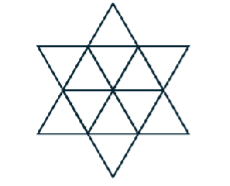

### Answer:
there are 12 triangles

### Question 12.6.2
How many different ways are there to make 50 cents using quarters, dimes, and nickels? Systematically
show all of the different ways.

In [17]:
solutions = []
for q in range(0, 3):  # 0,1,2 quarters (3*25=75 > 50)
    for d in range(0, 6):  # up to 5 dimes (5*10=50)
        for n in range(0, 11):  # up to 10 nickels
            total = 25*q + 10*d + 5*n
            if total == 50:
                solutions.append((q,d,n))
len(solutions), solutions


(10,
 [(0, 0, 10),
  (0, 1, 8),
  (0, 2, 6),
  (0, 3, 4),
  (0, 4, 2),
  (0, 5, 0),
  (1, 0, 5),
  (1, 1, 3),
  (1, 2, 1),
  (2, 0, 0)])

### Question 12.6.4
Recall that a valid name in Python can consist of upper- and lowercase letters, digits, and underscore
characters, but cannot start with a digit. How many valid Python names of length 3 or less are there?
Explain and show your calculations.

In [18]:
letters = 52
underscore = 1
first_choices = letters + underscore  # 53
other_choices = letters + underscore + 10  # 63

total = first_choices * (1 + other_choices + other_choices**2)
# Wait: for length 1 it's first_choices * 1; length2: first_choices*other_choices; length3: first_choices*other_choices**2
total = first_choices + first_choices*other_choices + first_choices*(other_choices**2)
total

213749

### Question 12.6.7
How many four-digit numbers have at least one 7 among their digits?
Hint: count the numbers that do not have any 7s.
### a) Explain and show your calculations.
$1000 to 9999, 7=9000-8 x9^3$
### b) Write code that iterates through all four-digit numbers and counts how many have 7 as at least one digit. Does the result match your calculation from Part a? It should.

In [19]:
# math
total_4digit = 9000
no_7 = 8 * (9**3)
with_at_least_one_7 = total_4digit - no_7
total_4digit, no_7, with_at_least_one_7

# brute force check
count = 0
for n in range(1000, 10000):
    if '7' in str(n):
        count += 1
count, count == with_at_least_one_7


(3168, True)